<a href="https://colab.research.google.com/github/Elvira-Babayeva/casual_analysis/blob/main/causal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Proposition 99: Causal Impact Analysis

Bu notebook 1989-cu ildə qüvvəyə minən Proposition 99 müdaxiləsinin California-da adambaşına siqaret satışına təsirini observational panel data ilə qiymətləndirir. Əsas sual budur: **Proposition 99 olmasaydı, 1989-cu ildən sonra California-da siqaret satışı necə dəyişərdi?**

In [1]:
!git clone https://github.com/Elvira-Babayeva/casual_analysis

Cloning into 'casual_analysis'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 34.73 KiB | 1.74 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [2]:
!ls /content/casual_analysis

data.csv  LICENSE  note_2.md


In [3]:
%cd /content/casual_analysis

/content/casual_analysis


In [4]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
!ls /content

casual_analysis  sample_data


In [6]:
!cp /content/data.csv /content/casual_analysis/

cp: cannot stat '/content/data.csv': No such file or directory


In [7]:
!cp /content/data.csv /content/casual_analysis/

cp: cannot stat '/content/data.csv': No such file or directory


## 1. Problem Definition

California treated unit, qalan 38 ştat donor/control pool, 1970–1988 pre-treatment, 1989–2000 isə post-treatment dövrüdür. Random assignment olmadığı üçün adi əvvəl/sonra müqayisəsi kifayət etmir. Əsas metod kimi Synthetic Control istifadə edilir; məqsəd pre-treatment dövründə California-nı yaxşı təkrarlayan çəkili control kombinasiyası qurmaqdır.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## 2. Data Loading

Məlumat layihənin `data` qovluğundan oxunur. İlk sətirlər, ölçü və sütun tipləri məlumatın düzgün yükləndiyini yoxlamağa kömək edir.

In [9]:
import pandas as pd

df = pd.read_csv("data.csv")
df

,state,year,cigsale,lnincome,beer,age15to24,retprice
0,Alabama,1970,89.800003,NaN,NaN,0.178862,39.599998
1,Alabama,1971,95.400002,NaN,NaN,0.179928,42.700001
2,Alabama,1972,101.099998,9.498476,NaN,0.180994,42.299999
3,Alabama,1973,102.900002,9.550107,NaN,0.182060,42.099998
4,Alabama,1974,108.199997,9.537163,NaN,0.183126,43.099998
...,...,...,...,...,...,...,...
1204,Wyoming,1996,110.300003,10.016768,24.6,NaN,162.500000
1205,Wyoming,1997,108.800003,10.025613,24.6,NaN,164.100006
1206,Wyoming,1998,102.900002,NaN,NaN,NaN,168.800003
1207,Wyoming,1999,104.800003,NaN,NaN,NaN,189.600006


In [10]:
print("Ölçü:", df.shape)
df.info()

Ölçü: (1209, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   state      1209 non-null   object 
 1   year       1209 non-null   int64  
 2   cigsale    1209 non-null   float64
 3   lnincome   1014 non-null   float64
 4   beer       546 non-null    float64
 5   age15to24  819 non-null    float64
 6   retprice   1209 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 66.2+ KB


Dataset 1,209 müşahidə və 7 sütundan ibarətdir: 39 ştat üçün 1970–2000 illəri. Outcome `cigsale` — adambaşına satılan siqaret qutularının sayıdır. Treated unit California, intervention başlanğıcı 1989-cu ildir.

## 3. Data Quality Check

Modeldən əvvəl missing values, təkrar state-year sətirləri, tiplər və panelin tamlığı yoxlanılır. Bu addım nəticənin məlumat xətası ilə yaranmadığına əmin olmaq üçündür.

In [11]:
print("Missing values:")
print(df.isna().sum())
print("\nTam təkrar sətirlər:", df.duplicated().sum())
print("Təkrar state-year sətirləri:", df.duplicated(["state", "year"]).sum())
print("\nData tipləri:")
print(df.dtypes)
print("\nŞtat sayı:", df["state"].nunique())
print("İl aralığı:", df["year"].min(), "-", df["year"].max())
print("California mövcuddur:", "California" in df["state"].unique())

state_coverage = df.groupby("state")["year"].agg(count="count", min_year="min", max_year="max")
incomplete_states = state_coverage.query("count != 31 or min_year != 1970 or max_year != 2000")
print("Natamam panelə malik ştatların sayı:", len(incomplete_states))

Missing values:
state          0
year           0
cigsale        0
lnincome     195
beer         663
age15to24    390
retprice       0
dtype: int64

Tam təkrar sətirlər: 0
Təkrar state-year sətirləri: 0

Data tipləri:
state         object
year           int64
cigsale      float64
lnincome     float64
beer         float64
age15to24    float64
retprice     float64
dtype: object

Ştat sayı: 39
İl aralığı: 1970 - 2000
California mövcuddur: True
Natamam panelə malik ştatların sayı: 0


`cigsale`, `state`, `year` və `retprice` tamdır; bəzi predictor sütunlarında missing values var. Bu sadə Synthetic Control yalnız tam olan `cigsale` trayektoriyasından istifadə etdiyi üçün predictor-ları imputasiya etmirik. Hər ştat üçün 31 il mövcuddur və təkrar state-year sətiri yoxdur.

## 4. Exploratory Data Analysis

### 4.1 Outcome summary

Əvvəlcə `cigsale` dəyişəninin miqyasını yoxlayırıq. Bu, sonrakı RMSE və treatment effect rəqəmlərini düzgün şərh etməyə imkan verir.

In [12]:
df["cigsale"].describe()

,cigsale
count,1209.000000
mean,118.893218
std,32.767404
min,40.700001
25%,100.900002
50%,116.300003
75%,130.500000
max,296.200012


Satışlar ştat və illər üzrə geniş dəyişir. Ortalama təxminən 118 paketdir; buna görə bir neçə paketlik pre-treatment xəta nisbətən kiçik, 15–20 paketlik davamlı fərq isə substantiv olaraq böyük sayıla bilər.

### 4.2 California cigarette sales over time

California-nın müşahidə olunan satış trayektoriyasına baxırıq. Şaquli xətt intervention başlanğıcını göstərir; qrafik yalnız təsviri müşahidədir, özü-özlüyündə causal effect göstərmir.

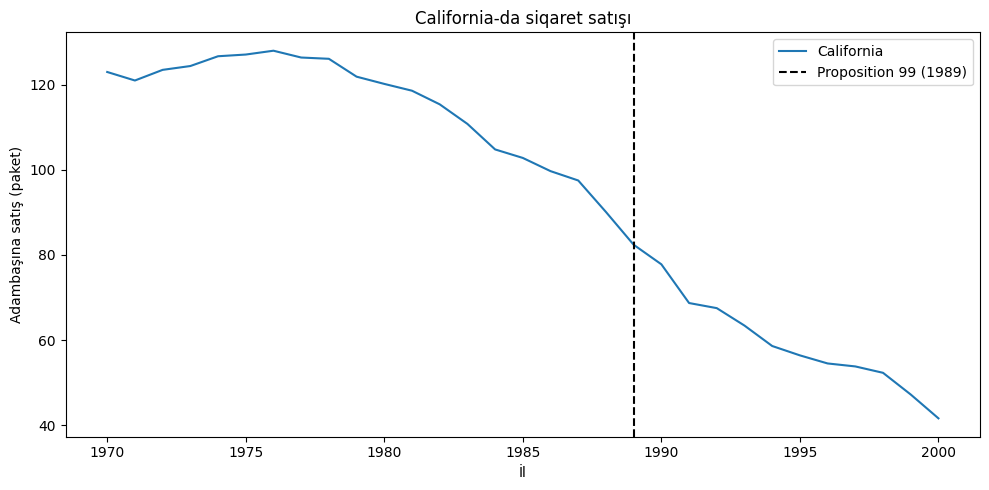

In [13]:
california = df[df["state"] == "California"].sort_values("year")

plt.figure(figsize=(10, 5))
plt.plot(california["year"], california["cigsale"], label="California")
plt.axvline(1989, color="black", linestyle="--", label="Proposition 99 (1989)")
plt.title("California-da siqaret satışı")
plt.xlabel("İl")
plt.ylabel("Adambaşına satış (paket)")
plt.legend()
plt.tight_layout()
plt.show()

California-da satış intervention-dan əvvəl də azalır və 1989-dan sonra azalma davam edir. Bu qrafik azalma olduğunu göstərir, lakin Proposition 99 olmasaydı nə baş verəcəyini göstərmədiyi üçün causal nəticə çıxarmaq olmaz.

### 4.3 California vs average control states

California-nı hər il digər ştatların sadə ortalaması ilə müqayisə edirik. Bu ilkin benchmark-dır və donorların California-ya nə qədər oxşar olduğunu görməyə kömək edir.

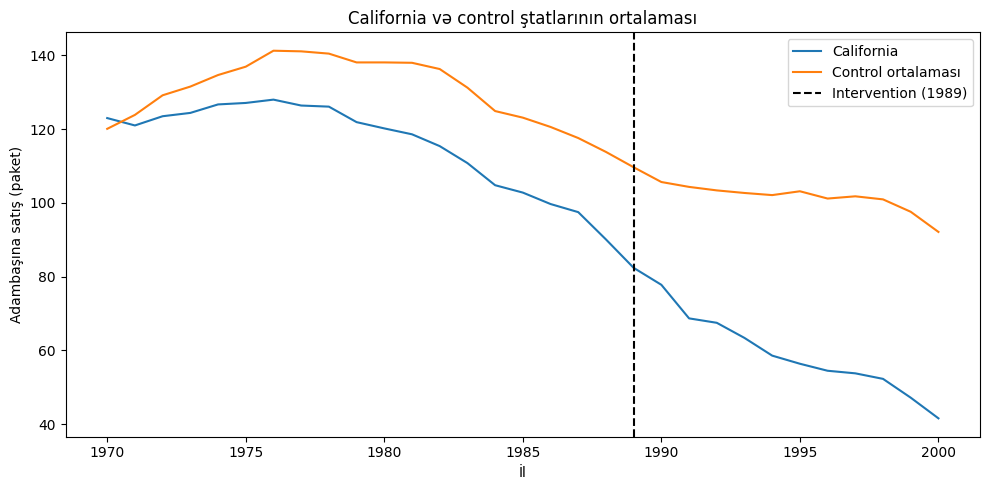

In [14]:
control_average = (
    df[df["state"] != "California"]
    .groupby("year")["cigsale"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(california["year"], california["cigsale"], label="California")
plt.plot(control_average.index, control_average.values, label="Control ortalaması")
plt.axvline(1989, color="black", linestyle="--", label="Intervention (1989)")
plt.title("California və control ştatlarının ortalaması")
plt.xlabel("İl")
plt.ylabel("Adambaşına satış (paket)")
plt.legend()
plt.tight_layout()
plt.show()

Pre-treatment dövründə hər iki sıra ümumi eniş göstərsə də, aralarındakı fərq sabit deyil: California control ortalamasından daha sürətli azalır. Bütün ştatlara eyni çəki vermək California üçün zəif counterfactual yaradır. Synthetic Control donor ştatlara fərqli çəkilər verərək pre-treatment uyğunluğunu yaxşılaşdırır.

### 4.4 Pre-treatment vs post-treatment summary

Dövrlər üzrə sadə ortalamalar satış səviyyəsinin necə dəyişdiyini ümumiləşdirir. Bu, təsviri müqayisədir və hələ causal estimate deyil.

In [15]:
ca_pre = california.loc[california["year"] < 1989, "cigsale"].mean()
ca_post = california.loc[california["year"] >= 1989, "cigsale"].mean()
control_pre = control_average.loc[control_average.index < 1989].mean()
control_post = control_average.loc[control_average.index >= 1989].mean()

period_summary = pd.DataFrame({
    "Qrup": ["California", "Control ortalaması"],
    "Pre-treatment": [ca_pre, control_pre],
    "Post-treatment": [ca_post, control_post]
})
period_summary.round(2)

,Qrup,Pre-treatment,Post-treatment
0,California,116.21,60.35
1,Control ortalaması,130.57,102.06


California-da orta satış post-treatment dövründə daha aşağıdır. Lakin sadə before/after müqayisəsi causal estimate deyil: milli trend, iqtisadi dəyişiklik və başqa amillər də satışları dəyişə bilər.

## 5. Treatment Definition

`treated` California müşahidələrini, `post` 1989 və sonrakı illəri, `did` isə bu iki şərtin birlikdə olduğu treated-post müşahidələri göstərir. Bu indikatorlar treatment vaxtını açıq şəkildə müəyyən edir.

In [16]:
df["treated"] = (df["state"] == "California").astype(int)
df["post"] = (df["year"] >= 1989).astype(int)
df["did"] = df["treated"] * df["post"]

df.loc[df["state"] == "California", ["state", "year", "treated", "post", "did"]].tail(15)

,state,year,treated,post,did
78,California,1986,1,0,0
79,California,1987,1,0,0
80,California,1988,1,0,0
81,California,1989,1,1,1
82,California,1990,1,1,1
83,California,1991,1,1,1
84,California,1992,1,1,1
85,California,1993,1,1,1
86,California,1994,1,1,1
87,California,1995,1,1,1


## 6. Synthetic Control

### 6.1 Preparing the Data

Outcome paneli year × state matrisinə çevrilir. Optimallaşdırma yalnız 1970–1988 dövründən öyrənir; post-treatment məlumat çəkilərin seçilməsində istifadə edilmir.

In [17]:
sales = df.pivot(index="year", columns="state", values="cigsale").sort_index()
pre_years = sales.index < 1989
post_years = sales.index >= 1989

actual_ca = sales["California"]
control_matrix = sales.drop(columns="California")

actual_pre = actual_ca.loc[pre_years].to_numpy()
controls_pre = control_matrix.loc[pre_years].to_numpy()
print("Pre-treatment matrisinin ölçüsü:", controls_pre.shape)
print("Post-treatment il sayı:", post_years.sum())

Pre-treatment matrisinin ölçüsü: (19, 38)
Post-treatment il sayı: 12


### 6.2 Estimating Weights

`scipy.optimize.minimize` pre-treatment mean squared error-i minimum edir. Bərabər çəkilər başlanğıc nöqtəsidir; SLSQP məhdudiyyətləri birbaşa nəzərə alır.

In [18]:
def objective(weights):
    synthetic_pre = controls_pre @ weights
    return np.mean((actual_pre - synthetic_pre) ** 2)

number_of_controls = control_matrix.shape[1]
initial_weights = np.ones(number_of_controls) / number_of_controls
bounds = [(0, 1)] * number_of_controls
constraint = {"type": "eq", "fun": lambda weights: weights.sum() - 1}

result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraint,
    options={"maxiter": 3000, "ftol": 1e-10}
)

weights = result.x
print("Optimization uğurludur:", result.success)
print("Çəkilərin cəmi:", weights.sum())
print("Ən kiçik çəki:", weights.min())

assert result.success
assert np.isclose(weights.sum(), 1, atol=1e-6)
assert weights.min() >= -1e-8

Optimization uğurludur: True
Çəkilərin cəmi: 1.0000000000031035
Ən kiçik çəki: 0.0


### 6.3 Building Synthetic California

Əvvəl meaningful çəkilərə baxırıq, sonra həmin çəkiləri bütün illərin control matrisinə tətbiq edib counterfactual qururuq.

In [19]:
weights_df = pd.DataFrame({
    "state": control_matrix.columns,
    "weight": weights
}).sort_values("weight", ascending=False)

weights_df[weights_df["weight"] > 0.01].round(4)

,state,weight
32,Utah,0.3939
17,Montana,0.2318
19,Nevada,0.2049
3,Connecticut,0.1091
20,New Hampshire,0.0454
2,Colorado,0.0148


Synthetic California əsasən Utah, Montana, Nevada və Connecticut-dan formalaşır; New Hampshire və Colorado daha kiçik rol oynayır. Bu çəkilər ştatların niyə oxşar olduğunu sübut etmir, yalnız pre-treatment outcome uyğunluğunu optimallaşdırır.

In [20]:
synthetic_ca = control_matrix.to_numpy() @ weights

counterfactual = pd.DataFrame({
    "year": sales.index,
    "actual_ca": actual_ca.to_numpy(),
    "synthetic_ca": synthetic_ca
})
counterfactual.head()

,year,actual_ca,synthetic_ca
0,1970,123.000000,117.424036
1,1971,121.000000,119.822966
2,1972,123.500000,124.646385
3,1973,124.400002,124.367230
4,1974,126.699997,126.473707


## 7. Counterfactual Validation

### 7.1 Pre-treatment Fit

Identifying assumption budur: Proposition 99 olmasaydı California Synthetic California trayektoriyasına yaxın hərəkət edərdi. Bu fərziyyəni sübut etmək olmur, amma treatment-dən əvvəlki uyğunluq onun credibility-si üçün vacib yoxlamadır.

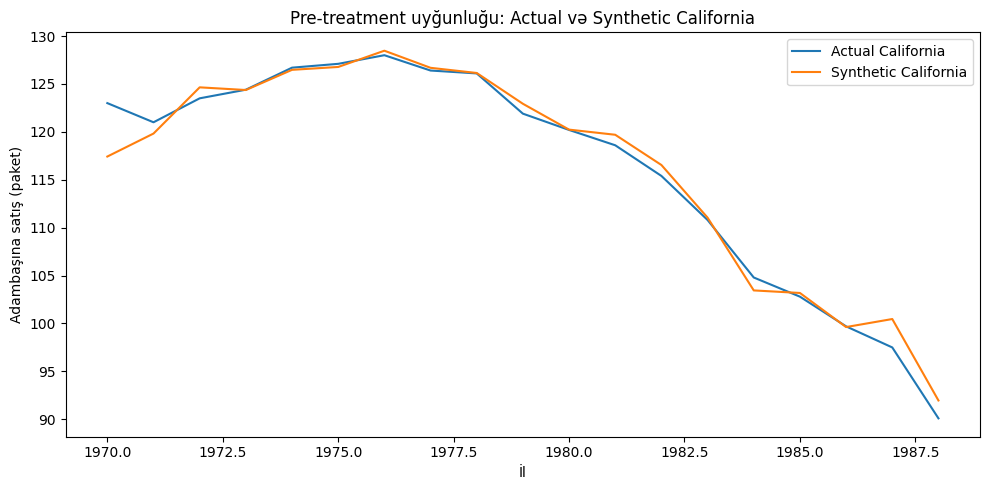

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(sales.index[pre_years], actual_ca.loc[pre_years], label="Actual California")
plt.plot(sales.index[pre_years], synthetic_ca[pre_years], label="Synthetic California")
plt.title("Pre-treatment uyğunluğu: Actual və Synthetic California")
plt.xlabel("İl")
plt.ylabel("Adambaşına satış (paket)")
plt.legend()
plt.tight_layout()
plt.show()

İki sıra 1970–1988 dövründə bir-birinə yaxın hərəkət edir. Bu yaxşı in-sample fit counterfactual-ı daha inandırıcı edir, lakin post-treatment dövrü üçün fərziyyəni avtomatik təsdiqləmir.

### 7.2 Pre-treatment RMSE

RMSE pre-treatment faktiki və synthetic satış arasındakı tipik xətanı outcome vahidində ölçür. Aşağı RMSE daha yaxşı uyğunluq deməkdir; universal cutoff yoxdur, ona görə satış miqyası və qrafiklə birlikdə şərh edilir.

In [22]:
pre_rmse = np.sqrt(
    np.mean((actual_ca.loc[pre_years].to_numpy() - synthetic_ca[pre_years]) ** 2)
)
print(f"Pre-treatment RMSE: {pre_rmse:.2f} paket")

Pre-treatment RMSE: 1.66 paket


RMSE təxminən 1.66 paketdir. California-nın pre-treatment satış səviyyəsi ilə müqayisədə bu kiçikdir və qrafikdəki yaxın uyğunluqla üst-üstə düşür.

## 8. Treatment Effect

Hər il üçün estimated effect belə hesablanır: $Effect_t = Actual_t - Synthetic_t$. Mənfi dəyər California satışının estimated no-treatment counterfactual-dan aşağı olduğunu göstərir. Post-treatment illərində bu fərqin ortalaması ATT-dir.

In [23]:
effect = actual_ca.to_numpy() - synthetic_ca
synth_att = effect[post_years].mean()

counterfactual["effect"] = effect
print(f"Estimated post-treatment ATT: {synth_att:.2f} paket/adambaşı")

Estimated post-treatment ATT: -19.51 paket/adambaşı


### 8.1 California vs Synthetic California

Bu əsas impact qrafiki müşahidə olunan California ilə estimated counterfactual-ı bütün dövr üzrə göstərir. Treatment-dən əvvəl yaxınlıq, sonra isə ayrılma gözlənilən causal pattern-dir.

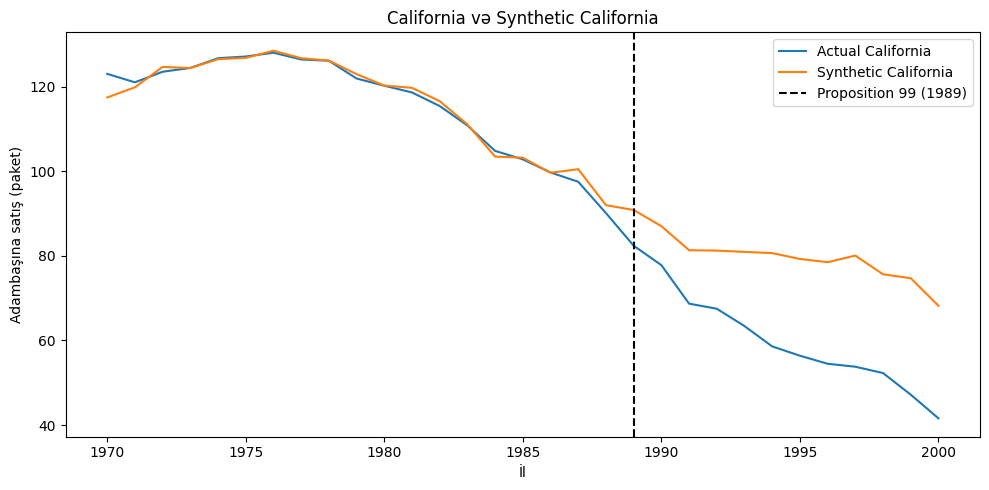

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(sales.index, actual_ca, label="Actual California")
plt.plot(sales.index, synthetic_ca, label="Synthetic California")
plt.axvline(1989, color="black", linestyle="--", label="Proposition 99 (1989)")
plt.title("California və Synthetic California")
plt.xlabel("İl")
plt.ylabel("Adambaşına satış (paket)")
plt.legend()
plt.tight_layout()
plt.show()

### 8.2 Effect Over Time

Gap qrafiki effect-in zamanla necə dəyişdiyini göstərir. Pre-treatment dəyərlərin sıfıra yaxın olması model uyğunluğuna, post-treatment davamlı mənfi gap isə satış azalmasına uyğun evidence verir.

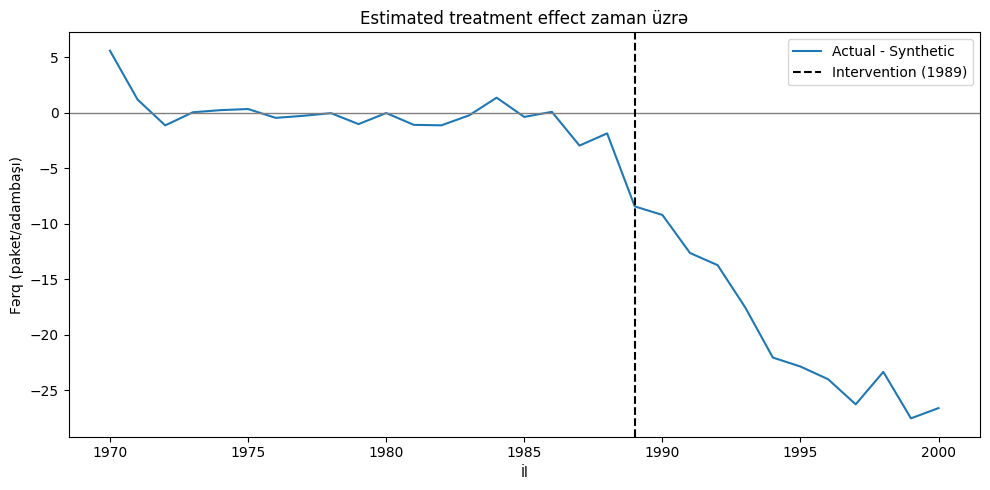

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(sales.index, effect, label="Actual - Synthetic")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(1989, color="black", linestyle="--", label="Intervention (1989)")
plt.title("Estimated treatment effect zaman üzrə")
plt.xlabel("İl")
plt.ylabel("Fərq (paket/adambaşı)")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 ATT

Estimated ATT **−19.51 paket/adambaşı**dır. Yəni 1989–2000 dövründə California satışları Synthetic California-nın proqnozlaşdırdığı no-Proposition-99 səviyyəsindən ildə orta hesabla təxminən 19.5 paket aşağıdır. Bu şərh Synthetic Control counterfactual fərziyyəsi etibarlı olduqda causal məna daşıyır.

## 9. Placebo Test

New Mexico-ya saxta 1989 intervention-u veririk. California real treatment aldığı üçün placebo donor pool-dan çıxarılır. Məqsəd yaxşı pre-treatment fit olan untreated ştatda eyni metodun böyük saxta effect yaradıb-yaratmadığını görməkdir.

In [26]:
placebo_state = "New Mexico"
untreated_pool = sales.drop(columns="California")
placebo_actual = untreated_pool[placebo_state]
placebo_controls = untreated_pool.drop(columns=placebo_state)
placebo_pre = placebo_actual.loc[pre_years].to_numpy()
placebo_controls_pre = placebo_controls.loc[pre_years].to_numpy()

def placebo_objective(placebo_weights):
    placebo_synthetic_pre = placebo_controls_pre @ placebo_weights
    return np.mean((placebo_pre - placebo_synthetic_pre) ** 2)

placebo_count = placebo_controls.shape[1]
placebo_result = minimize(
    placebo_objective,
    np.ones(placebo_count) / placebo_count,
    method="SLSQP",
    bounds=[(0, 1)] * placebo_count,
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
    options={"maxiter": 3000, "ftol": 1e-10}
)

placebo_weights = placebo_result.x
assert placebo_result.success
assert np.isclose(placebo_weights.sum(), 1, atol=1e-6)
assert placebo_weights.min() >= -1e-8

In [27]:
placebo_synthetic = placebo_controls.to_numpy() @ placebo_weights
placebo_effect = placebo_actual.to_numpy() - placebo_synthetic
placebo_rmse = np.sqrt(np.mean(placebo_effect[pre_years] ** 2))
placebo_att = placebo_effect[post_years].mean()

print(f"{placebo_state} pre-treatment RMSE: {placebo_rmse:.2f} paket")
print(f"{placebo_state} placebo ATT: {placebo_att:.2f} paket/adambaşı")

New Mexico pre-treatment RMSE: 1.39 paket
New Mexico placebo ATT: -2.30 paket/adambaşı


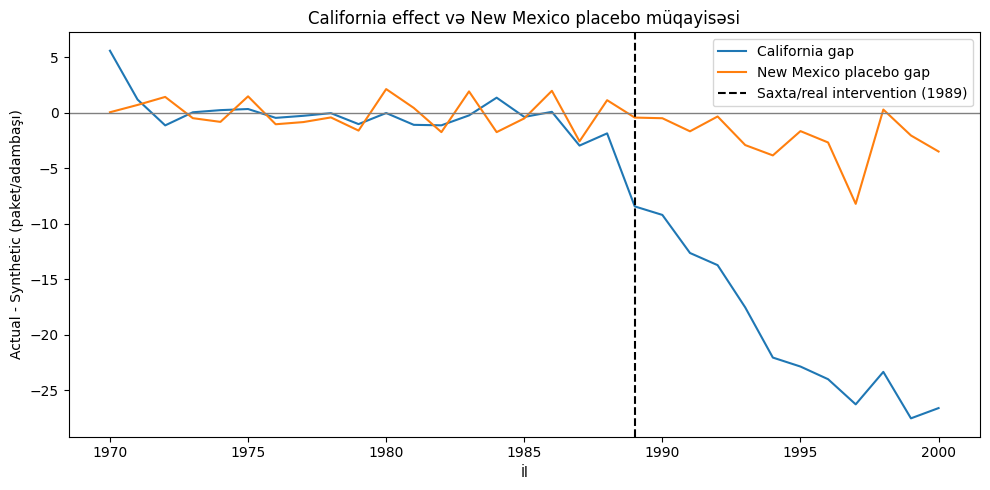

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(sales.index, effect, label="California gap")
plt.plot(sales.index, placebo_effect, label="New Mexico placebo gap")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(1989, color="black", linestyle="--", label="Saxta/real intervention (1989)")
plt.title("California effect və New Mexico placebo müqayisəsi")
plt.xlabel("İl")
plt.ylabel("Actual - Synthetic (paket/adambaşı)")
plt.legend()
plt.tight_layout()
plt.show()

New Mexico üçün pre-treatment RMSE 1.39 paket, placebo ATT isə −2.30 paketdir. Placebo-nun pre-treatment fit-i məqbuldur, amma post-treatment gap California-nın −19.51 paketlik gap-indən xeyli kiçikdir. Bu bir placebo nəticəni dəstəkləyir, lakin formal inference və bütün ştatlar üzrə placebo distribution-u əvəz etmir.

## 10. Difference-in-Differences Comparison

Secondary benchmark kimi sadə DiD hesablayırıq:

$$ATT_{DiD}=(Y_{CA,post}-Y_{CA,pre})-(Y_{Control,post}-Y_{Control,pre})$$

Bu yanaşma California ilə sadə control ortalamasının treatment olmasaydı parallel trends izləyəcəyini fərz edir.

In [29]:
did_att = (ca_post - ca_pre) - (control_post - control_pre)
print(f"Sadə Difference-in-Differences ATT: {did_att:.2f} paket/adambaşı")

Sadə Difference-in-Differences ATT: -27.35 paket/adambaşı


### Parallel Trends Check

Parallel trends-i sübut etmək mümkün deyil, amma pre-treatment trayektoriyalarına və aralarındakı gap-in sabitliyinə baxmaq assumption-un plausibility-si haqqında evidence verir.

Pre-treatment gap trendi: -1.23 paket/il
1970 gap: 2.92; 1988 gap: -23.72


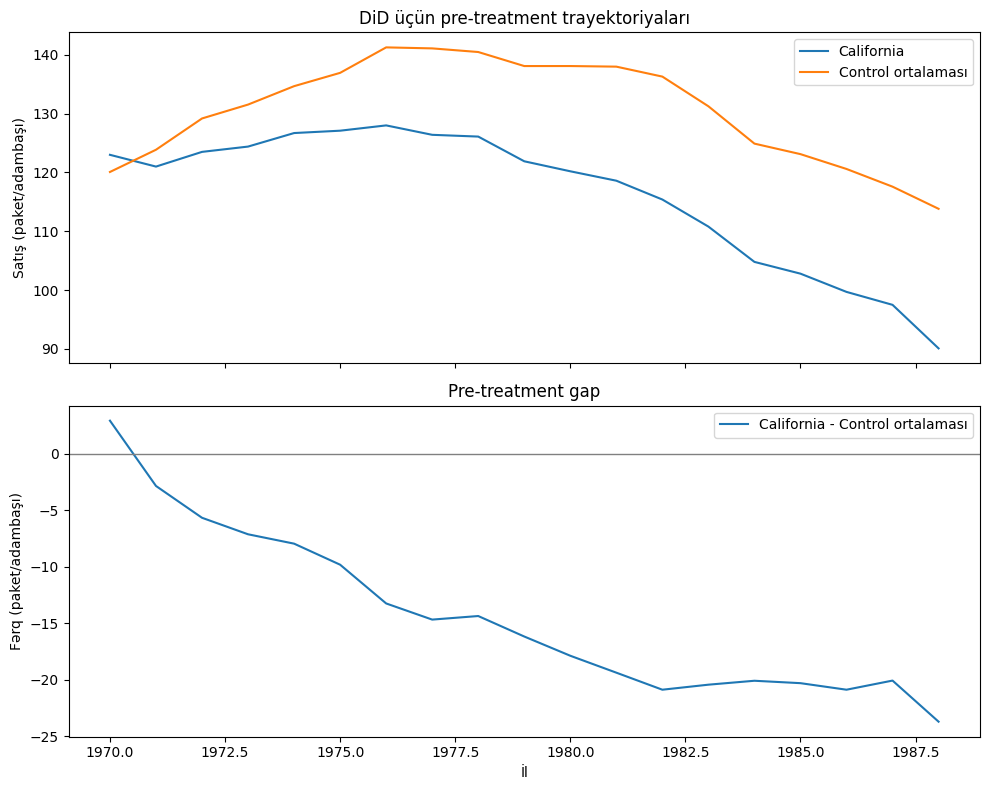

In [30]:
pre_gap = actual_ca.loc[pre_years] - control_average.loc[pre_years]
pre_gap_slope = np.polyfit(pre_gap.index, pre_gap.values, 1)[0]
print(f"Pre-treatment gap trendi: {pre_gap_slope:.2f} paket/il")
print(f"1970 gap: {pre_gap.iloc[0]:.2f}; 1988 gap: {pre_gap.iloc[-1]:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(actual_ca.loc[pre_years].index, actual_ca.loc[pre_years], label="California")
axes[0].plot(control_average.loc[pre_years].index, control_average.loc[pre_years], label="Control ortalaması")
axes[0].set_title("DiD üçün pre-treatment trayektoriyaları")
axes[0].set_ylabel("Satış (paket/adambaşı)")
axes[0].legend()

axes[1].plot(pre_gap.index, pre_gap.values, label="California - Control ortalaması")
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set_title("Pre-treatment gap")
axes[1].set_xlabel("İl")
axes[1].set_ylabel("Fərq (paket/adambaşı)")
axes[1].legend()
plt.tight_layout()
plt.show()

Pre-treatment gap 1970-də 2.92-dən 1988-də −23.72-yə düşür və illik trend təxminən −1.23 paketdir. Buna görə parallel trends assumption sadə control ortalaması üçün inandırıcı görünmür. DiD və Synthetic Control eyni mənfi işarə versə də, DiD-in −27.35 paketlik ölçüsü bu trend pozuntusuna görə daha zəif etibarlıdır.

## 11. Bonus: EconML Meta-Learners və Heterogeneous Effects

Bu bonus bölmədə EconML ilə T-Learner və S-Learner qurulur. Məqsəd əsas Synthetic Control nəticəsini əvəz etmək deyil, fərqli modeling yanaşmasının effect-in işarəsi və zaman üzrə dəyişməsi haqqında nə göstərdiyini yoxlamaqdır.

Meta-learner-lər unconfoundedness və overlap assumptions tələb edir. Burada treatment yalnız California-nın 12 post-treatment müşahidəsində olduğu üçün bu assumptions güclü və tam yoxlanmayan fərziyyələrdir. Buna görə nəticələr exploratory robustness check kimi şərh edilir.

### 11.1 Features və Treatment Data

Features yalnız calendar time və treatment-dən əvvəl hesablanan state-level göstəricilərdir: pre-treatment satış ortalaması, satış trend-i və retail price ortalaması. Post-treatment retprice birbaşa feature kimi istifadə edilmir, çünki vergi müdaxiləsinin təsir etdiyi mediator ola bilər.

In [33]:
from econml.metalearners import TLearner, SLearner
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [32]:
pip install econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 10.8 MB/s eta 0:00:00


After installing `econml`, please restart the runtime by going to `Runtime > Restart runtime...` in the Colab menu. This is necessary for the newly installed library to be recognized.

In [34]:
pre_data = df[df["year"] < 1989].copy()

state_features = pre_data.groupby("state").agg(
    pre_sales_mean=("cigsale", "mean"),
    pre_price_mean=("retprice", "mean")
)

state_trends = {}
for state, state_data in pre_data.groupby("state"):
    state_trends[state] = np.polyfit(state_data["year"], state_data["cigsale"], 1)[0]

state_features["pre_sales_trend"] = pd.Series(state_trends)

ml_df = df.merge(state_features.reset_index(), on="state", how="left")
ml_df["year_centered"] = ml_df["year"] - 1989

feature_columns = [
    "year_centered",
    "pre_sales_mean",
    "pre_sales_trend",
    "pre_price_mean"
]

X = ml_df[feature_columns].to_numpy()
Y = ml_df["cigsale"].to_numpy()
T = ml_df["did"].to_numpy()

print("Control müşahidələri:", (T == 0).sum())
print("Treated müşahidələr:", (T == 1).sum())
print("Feature missing values:", ml_df[feature_columns].isna().sum().sum())

Control müşahidələri: 1197
Treated müşahidələr: 12
Feature missing values: 0


### 11.2 T-Learner və S-Learner

T-Learner treatment və control üçün iki ayrı outcome modeli qurur. S-Learner isə treatment indikatorunu eyni outcome modelində əlavə feature kimi istifadə edir. Hər ikisində sadə və regularized Ridge modeli seçilir; bu, kiçik treated sample üçün mürəkkəb modeldən daha şəffafdır.

In [35]:
t_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
s_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

t_learner = TLearner(models=t_model)
s_learner = SLearner(overall_model=s_model)

t_learner.fit(Y, T, X=X)
s_learner.fit(Y, T, X=X)

In [36]:
california_post_ml = ml_df[
    (ml_df["state"] == "California") & (ml_df["year"] >= 1989)
].sort_values("year")

X_ca_post = california_post_ml[feature_columns].to_numpy()
t_learner_cate = t_learner.effect(X_ca_post)
s_learner_effect = s_learner.effect(X_ca_post)

t_learner_att = t_learner_cate.mean()
s_learner_att = s_learner_effect.mean()

econml_effects = pd.DataFrame({
    "year": california_post_ml["year"].to_numpy(),
    "Synthetic Control effect": effect[post_years],
    "T-Learner CATE": t_learner_cate,
    "S-Learner effect": s_learner_effect
})

print(f"T-Learner orta CATE: {t_learner_att:.2f} paket/adambaşı")
print(f"S-Learner orta effect: {s_learner_att:.2f} paket/adambaşı")
econml_effects.round(2)

T-Learner orta CATE: -26.89 paket/adambaşı
S-Learner orta effect: -26.85 paket/adambaşı


,year,Synthetic Control effect,T-Learner CATE,S-Learner effect
0,1989,-8.44,-18.54,-26.85
1,1990,-9.21,-20.06,-26.85
2,1991,-12.63,-21.58,-26.85
3,1992,-13.73,-23.10,-26.85
4,1993,-17.53,-24.61,-26.85
5,1994,-22.05,-26.13,-26.85
6,1995,-22.86,-27.65,-26.85
7,1996,-24.00,-29.17,-26.85
8,1997,-26.26,-30.69,-26.85
9,1998,-23.34,-32.20,-26.85


In [37]:
econml_effects["Dövr"] = np.where(
    econml_effects["year"] <= 1994,
    "1989–1994",
    "1995–2000"
)

heterogeneity_summary = (
    econml_effects.groupby("Dövr")["T-Learner CATE"]
    .mean()
    .reset_index()
)
heterogeneity_summary.round(2)

,Dövr,T-Learner CATE
0,1989–1994,-22.34
1,1995–2000,-31.44


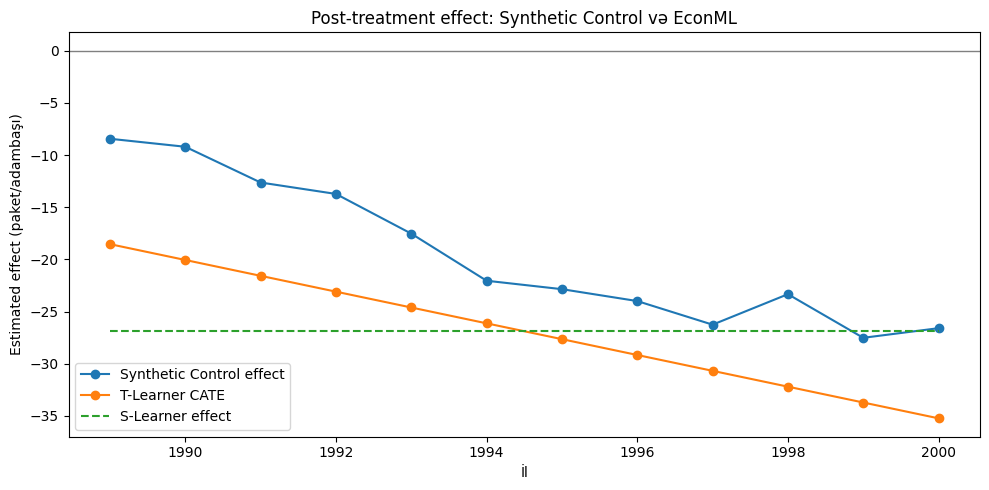

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(
    econml_effects["year"],
    econml_effects["Synthetic Control effect"],
    marker="o",
    label="Synthetic Control effect"
)
plt.plot(
    econml_effects["year"],
    econml_effects["T-Learner CATE"],
    marker="o",
    label="T-Learner CATE"
)
plt.plot(
    econml_effects["year"],
    econml_effects["S-Learner effect"],
    linestyle="--",
    label="S-Learner effect"
)
plt.axhline(0, color="gray", linewidth=1)
plt.title("Post-treatment effect: Synthetic Control və EconML")
plt.xlabel("İl")
plt.ylabel("Estimated effect (paket/adambaşı)")
plt.legend()
plt.tight_layout()
plt.show()

T-Learner orta CATE-ni **−26.89**, S-Learner isə orta effect-i **−26.85 paket/adambaşı** qiymətləndirir. Hər iki meta-learner əsas Synthetic Control kimi mənfi effect göstərir, lakin magnitude daha böyükdür.

T-Learner üzrə orta CATE 1989–1994-də −22.34, 1995–2000-də −31.44 paketdir. Bu, estimated effect-in zamanla güclənməsinə uyğun exploratory pattern-dir. Lakin modeldə yalnız 12 treated müşahidə var və time heterogeneity əsasən linear outcome modelindən gəlir. Buna görə bu fərqi güclü heterogeneous causal evidence kimi qəbul etmək olmaz; cross-state treatment heterogeneity isə yalnız bir treated state olduğuna görə qiymətləndirilə bilmir.

## 12. Results Summary

Əsas diagnostic və estimates bir cədvəldə toplanır ki, metodlar və placebo asan müqayisə olunsun.

In [39]:
results = pd.DataFrame({
    "Metric": [
        "Synthetic Control pre-treatment RMSE",
        "Synthetic Control ATT",
        "Difference-in-Differences ATT",
        "New Mexico placebo pre-treatment RMSE",
        "New Mexico placebo ATT"
    ],
    "Value (paket/adambaşı)": [
        pre_rmse,
        synth_att,
        did_att,
        placebo_rmse,
        placebo_att
    ]
})
results.round(2)

,Metric,Value (paket/adambaşı)
0,Synthetic Control pre-treatment RMSE,1.66
1,Synthetic Control ATT,-19.51
2,Difference-in-Differences ATT,-27.35
3,New Mexico placebo pre-treatment RMSE,1.39
4,New Mexico placebo ATT,-2.30


## 13. Assumptions and Limitations

Nəticəni causal şərh etmək üçün əsas assumption budur: Proposition 99 olmasaydı California Synthetic California-ya yaxın trayektoriya izləyərdi. Yaxşı pre-treatment fit və kiçik placebo effect bu assumption-a müəyyən dəstək verir, amma onu sübut etmir.

Əsas threats:

- eyni vaxtda başlayan başqa California-specific siyasətlər;
- demoqrafik və iqtisadi dəyişikliklər, miqrasiya və unobserved shocks;
- siqaret satışının ölçülməsi və ya hesabat qaydasında dəyişiklik;
- spillover effects və donor ştatlarda oxşar anti-smoking policies;
- 1989-dan əvvəl anticipation effects;
- outcome-only modelin missing predictor-lardakı əlavə məlumatdan istifadə etməməsi;
- yalnız bir placebo test-in formal statistical inference verməməsi;
- EconML hissəsində cəmi 12 treated müşahidə, zəif overlap və tam təmin olunmayan unconfoundedness assumption-u.

Bu observational study-dir, randomized controlled experiment deyil. Buna görə Proposition 99-un bütün azalmanı qəti şəkildə yaratdığını demək olmaz.

## 14. Conclusion

Synthetic California 1970–1988 dövründə actual California-nı yaxşı təkrarlayır (RMSE = 1.66 paket), 1989-dan sonra isə iki trayektoriya ayrılır. Estimated ATT −19.51 paket/adambaşıdır və New Mexico placebo effect-indən (−2.30) xeyli böyükdür. Sadə DiD də mənfi nəticə verir (−27.35), lakin pre-treatment parallel trends zəif olduğuna görə əsas estimate kimi götürülmür.

Nəticə Proposition 99-un siqaret satışını azaltdığına uyğun evidence verir — **o şərtlə ki**, müdaxilə olmasaydı California Synthetic California-nın trayektoriyasını izləyəcəkdi və eyni dövrdə California-ya xas başqa shock nəticəni izah etmir. EconML T-Learner və S-Learner də mənfi effect göstərir, lakin yalnız 12 treated müşahidəyə görə bu bonus nəticələr əsas estimate deyil, exploratory robustness check-dir.